In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import ase
import os
import ase.io
from tqdm.notebook import tqdm
import time

In [2]:
def get_size(df):
    return len(df.structure)

In [3]:
def get_mod_time(file_path):
    modification_time = os.path.getmtime(file_path)
    current_time = time.time()
    return current_time - modification_time

def check_second_to_last_line(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        try:
            second_to_last_line = lines[-2].strip()
        except:
            return False
        
    return second_to_last_line == 'JOB DONE.'
def check_last_line(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        try:
            last_line = lines[-1].strip()
        except:
            return True
        
    if (last_line == 'stopping ...') or 'not converged' in last_line:
        return True
    else:
        return False

def check_converge(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if "No convergence has been achieved" in line:
            return False
    return True

def check_temp(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if "unable to create directory temp" in line:
            return True
    return False

In [4]:
par_el = 'run_full'
root = '/blue/hennig/jasongibson/diff_model'
root = f'{root}/materials/{par_el}/mp_relaxed/'
df = pd.read_pickle(f'pkl_files/df_{par_el}_pred_m3gnet_eah.pkl')

In [5]:
def get_mod_time2(file_path):
    # Get the modification time
    modification_time = os.path.getmtime(file_path)
    # Get the current time
    current_time = time.time()
    # Calculate the difference in seconds
    time_diff = current_time - modification_time

    # Convert seconds to days, hours, minutes, and seconds
    days = int(time_diff // (24 * 3600))
    time_diff = time_diff % (24 * 3600)
    hours = int(time_diff // 3600)
    time_diff %= 3600
    minutes = int(time_diff // 60)
    seconds = int(time_diff % 60)

    return f"{days} days, {hours} hours, {minutes} minutes, {seconds} seconds ago"

# Example usage


In [6]:
inds = []
complete = []
fail = []
running = []
temp = []
cont = []
for index, row in tqdm(df.iterrows(),total=len(df)):
    jobdir = f'{root}{row.name}/'
        
    filename = jobdir+"/relax.out"
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        complete.append(index)
    elif os.path.isfile(jobdir+'phonon_2x2x2/CRASH'):
        fail.append(index)
        temp.append(index)
    elif os.path.isfile(filename):
        if check_second_to_last_line(filename)==False:
            fail.append(index)
        # elif (os.path.isfile(filename)) and not (os.path.isdir(jobdir+'phonon_2x2x2')):
        #     fail.append(index)    
        elif os.path.isfile(jobdir+'phonon_2x2x2/phonon_2x2x2.out'):
            if get_mod_time(jobdir+'phonon_2x2x2/phonon_2x2x2.out') < 1000:
                # print(jobdir)
                # print(get_mod_time(jobdir+'phonon_2x2x2/phonon_2x2x2.out'))
                running.append(index)            
                if get_mod_time(jobdir+'phonon_2x2x2/phonon_2x2x2.out') > 520:
                    cont.append(index)      
            elif not check_converge(jobdir+'phonon_2x2x2/phonon_2x2x2.out'):
                fail.append(index)
            elif check_temp(jobdir+'phonon_2x2x2/phonon_2x2x2.out'):
                inds.append(index)    
            elif not check_last_line(jobdir+'phonon_2x2x2/phonon_2x2x2.out'):
                inds.append(index)
            else:
                fail.append(index)
        else:
            inds.append(index)

    else:
        inds.append(index)

print(len(fail))

  0%|          | 0/6173 [00:00<?, ?it/s]

3136


In [7]:
df.shape

(6173, 28)

In [8]:
len(cont)

0

In [9]:
net = inds
df = df.loc[net]
# print(df.shape)

In [10]:
# df[['index','formula','tcad_mp','mp_eah']]

In [11]:
df = df.loc[df.natoms <=12]
df.sort_values('natoms',inplace = True)
df.shape

(1685, 28)

In [12]:
len(complete)#+len(fail)

1340

In [13]:
len(fail)

3136

In [14]:
len(inds)

1685

In [15]:
len(running)

12

In [16]:
# inds

In [17]:
# par_el = 'Si'
# root = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'
# with open(root + "list_ele",'r') as fp:
#     list_uniq = fp.readlines()

# list_uniq = [int(line.strip().split('/')[0]) for line in list_uniq]

In [18]:
df.columns

Index(['dirs', 'Structure', 'final_E', 'PBE', 'GLLB-SC', 'HSE', 'SCAN',
       'E_form', 'is_metal', 'formula', 'structure', 'sgn', 'Freq_meV', 'a2F',
       'target', 'species', 'data', 'pred_avg', 'pred_avg_m3g', 'lamb_m3g',
       'w2_m3g', 'wlog_m3g', 'tc_m3g', 'tcad_m3g', 'Sorted_Elements', 'eah',
       'natoms', 'mp_eah'],
      dtype='object')

In [19]:
# df.sort_values('sgn',inplace=True,ascending=False)
df.sort_values(by=['sgn','natoms','tcad_m3g'],ascending=[False,True,False],inplace=True)
# df = df.loc[~df.formula.str.contains('La')]
# d = df.loc[~df.formula.str.contains('Tc')]
# dt = df.loc[df.formula.str.contains('Tc')]

In [20]:
len(df)

1685

In [21]:
with open(root+'list_ele', "w") as file:
    for item, _ in df.iterrows():
        # Write each item to the file followed by a newline
        # file.write(f"{item}\n")        
        file.write(f"{item}/phonon_2x2x2\n")

In [21]:
df.head()

,final_E,PBE,GLLB-SC,HSE,SCAN,E_form,is_metal,structure,formula,pred_avg,...,tc,tcad,sgn,parent_formula,mp_id,Sorted_Elements,eah,natoms,mp_eah,tcad_mp
id,,,,,,,,,,,,,,,,,,,,,
681270,-118.059517,-0.006224,0.456891,-0.006203,0.264876,-0.258162,True,"(Atom('V', [2.772293394378397, 0.1497274991906...",Ir4Mo4Ru2V2,"[0.0007935892395410401, 4.198746748828078e-05,...",...,5.086266,5.456103,51,NbIr,mp-1095683,IrMoRuV,0.090291,12,0.061785,5.228398
549592,-118.199600,-0.005144,0.621647,-0.006496,0.285673,-0.096224,True,"(Atom('Nb', [4.286473087397534, 2.501115815260...",Nb2Ru9W,"[0.00013296950608987282, 1.0176407854116501e-0...",...,4.961364,5.115022,166,TaCo3,mp-7851,NbRuW,-0.019070,12,0.052896,5.092146
681625,-120.479324,-0.006275,0.521991,-0.006562,0.339511,-0.420308,True,"(Atom('Ti', [3.026972070357922, 0.963380196160...",Os4Ru2Ti2V4,"[0.0045234750166268465, 1.362975658571089e-05,...",...,4.953382,5.369614,51,NbIr,mp-1095683,OsRuTiV,0.004381,12,0.089321,5.100593
108862,-129.493103,-0.006289,0.511315,-0.006070,0.222999,-0.128358,True,"(Atom('Mo', [2.8143606629458953, 4.50725779121...",Ir2Mo2Ru4W4,"[0.0005610009101110083, 9.71823384621425e-05, ...",...,4.963087,5.028489,51,TaIr,mp-571499,IrMoRuW,0.041052,12,0.077770,5.111738
176497,-120.334686,-0.006762,0.373602,-0.007663,0.176772,-0.262086,True,"(Atom('Zr', [2.632740869042656, 1.520014525237...",Mo6Ru2Zr4,"[0.0025284092322133615, 4.1812988435272005e-05...",...,5.007873,5.163918,194,TiMn2,mp-1949,MoRuZr,0.073455,12,0.055185,5.165198


In [22]:
df.loc[~df.formula.str.contains('Tc')].shape

(41, 23)

In [23]:
df.shape

(41, 23)

In [24]:
len(df)

41

In [23]:
root = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'

def get_tot_ph(df):
    jobdir = f'{root}{df.name}/'
        
    filename = jobdir+"/relax.out"
    try:
        atom_obj = ase.io.read(filename)
    except:
        return np.nan   
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
        freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
    else:
        phdos = np.nan
    return phdos 

def get_site_ph(df):
    jobdir = f'{root}{df.name}/'
    filename = jobdir+"/relax.out"
    try:
        atom_obj = ase.io.read(filename)
    except:
        return np.nan   
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
        freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
    else:
        site_proj_phdos = np.nan
    return site_proj_phdos 

def get_freq(df):
    jobdir = f'{root}{df.name}/'
    try:
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
    except:
        return np.nan
    if os.path.isfile(jobdir+'phonon_2x2x2/.dos'):
        filename = jobdir+"/relax.out"
        atom_obj = ase.io.read(filename)
        freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
    else:
        freq = np.nan
    return freq

df['freq'] = df.apply(get_freq,axis=1)
df['phdos'] = df.apply(get_tot_ph,axis=1)
df['site_phdos'] = df.apply(get_site_ph,axis=1)

Exception ignored in: <generator object _iread at 0x1483dbb91e40>
Traceback (most recent call last):
  File "/home/jasongibson/miniconda3/envs/e3nn/lib/python3.9/site-packages/ase/io/formats.py", line 809, in _iread
    yield dct['atoms']
KeyboardInterrupt: 


In [33]:
print(df.shape)
df.dropna(axis=0,inplace=True)
df.shape

(200, 19)


(28, 19)

In [34]:
def get_dyn_stable(df):
    for freq, phdos in zip(df.freq,df.phdos):
        if (freq < 0) & (phdos > 0.1):
            return False
    return True
df['dyn_stable'] = df.apply(get_dyn_stable,axis=1)

In [35]:
# plt.plot(df.loc[159493].freq,df.loc[159493].phdos)

In [36]:
df = df.loc[df.dyn_stable]
df.shape

(25, 20)

In [37]:
df.to_pickle(f'pickle_files/df_dyn_stab_{par_el}.pkl')

In [87]:
root_relaxed = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'
with open(root_relaxed+'list_ele_ph', "w") as file:
    for item in df.index:
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [90]:
!blue_quota

Storage quotas for group 'hennig':
Filesystem    Use     Quota    Limit    Grace       Files
------------  ------  -------  -------  -------  --------
blue          9.737T  10T      10T      -        35469482

Storage quotas for user 'jasongibson':
Filesystem    Use     Quota    Limit    Grace      Files
------------  ------  -------  -------  -------  -------
blue          1.127T  0k       0k       -        4398184

See additional options with 'blue_quota -h'


In [88]:
df = df.loc[df.dyn_stable]

df.shape

(25, 20)

KeyError: 1960

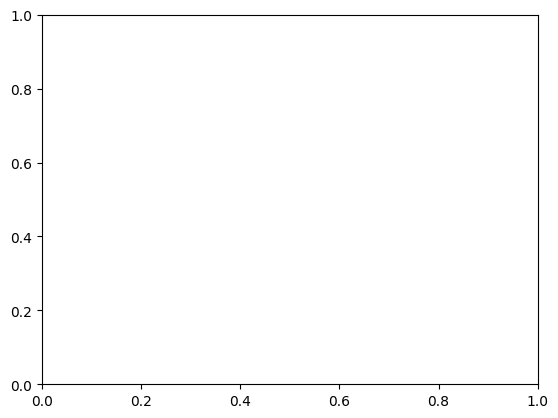

In [89]:
ind = 1960
fig, ax = plt.subplots(1,1)

ax.plot(df.loc[ind]['freq'], df.loc[ind]['phdos'],label="Total")

for i in range(1,len(df.loc[ind].site_phdos)):
    ax.plot(df.loc[ind]['freq'], df.loc[ind].site_phdos[i],'--',label="Site "+str(i+1))

ax.set_ylabel(r"F($\omega$) states/meV/unit_cell")
ax.legend()
#axs[0].set_ylim(0,1)

In [ ]:
df_null = df.loc[df.freq.isnull()]

In [15]:
root

'/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/'

In [24]:
inds = []
for ind in df_null.index:
    d = root+f'{ind}/phonon_2x2x2/'
    if os.path.isfile(d+'CRASH') == False:
        print(d)
        inds.append(ind)
    # else:
        # print(d)
    #     print(os.listdir(d))

/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/58517/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/49588/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/44525/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/46725/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/53432/phonon_2x2x2/
/blue/hennig/jasongibson/elemental_sub/materials/Mg/mp_relaxed/61819/phonon_2x2x2/


In [25]:
root_relaxed = f'/blue/hennig/jasongibson/elemental_sub/materials/{par_el}/mp_relaxed/'
with open(root_relaxed+'list_ele', "w") as file:
    for item in inds:
        # Write each item to the file followed by a newline
        file.write(f"{item}\n")

In [4]:
root = '/blue/hennig/jasongibson/elemental_sub/Be/mp_relaxed/1655'
jobdir = root +'/qe_test/test_2'

filename = jobdir+"/relax.out"
atom_obj = ase.io.read(filename)

In [5]:
Ph_2x2x2_interpolated_Freq_meV = []
Ph_2x2x2_interpolated_Tot_DOS = []
Ph_2x2x2_interpolated_Site_Proj_DOS = []


freq, phdos, site_proj_phdos = get_freq_phonon_2x2x2_interpolated_DOS(jobdir +"/phonon_2x2x2/"+".dos", atom_obj.get_global_number_of_atoms())
Ph_2x2x2_interpolated_Freq_meV.append(freq)
Ph_2x2x2_interpolated_Tot_DOS.append(phdos)
Ph_2x2x2_interpolated_Site_Proj_DOS.append(site_proj_phdos)


<Figure size 640x480 with 0 Axes>

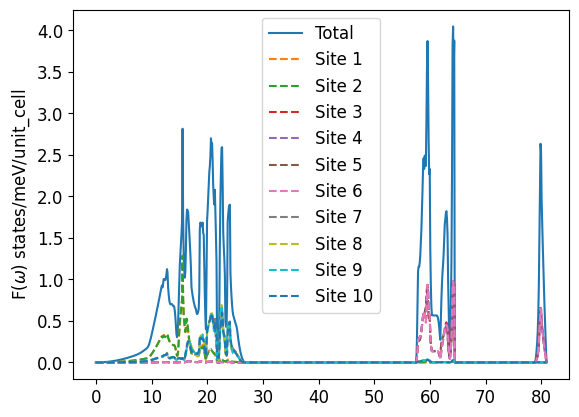

In [7]:
plt.clf()
plt.rcParams.update({'font.size': 12})
# plt.rcParams["font.family"] = "Times New Roman"

plt.subplots_adjust(left=0.15,bottom=0.07,right=0.99,top=0.99,hspace=0.05)
fig, ax = plt.subplots(1,1)

# mat_data = data3.iloc[2]#data.iloc[data[data["comp_name"]=="Mg1B2_JVASP_19821"].index[0]]

ax.plot(freq, phdos,label="Total")

for i in range(0,atom_obj.get_global_number_of_atoms()):
    ax.plot(freq, site_proj_phdos[i],'--',label="Site "+str(i+1))

ax.set_ylabel(r"F($\omega$) states/meV/unit_cell")
ax.legend()
#axs[0].set_ylim(0,1)

# axs[1].plot(mat_data["a2F_Freq_meV_sigma_2"],mat_data["a2F_sigma_2"])



# axs[1].set_ylabel(r"$\alpha^2$F($\omega$)")

# axs[2].plot(mat_data["Ph_2x2x2_interpolated_Freq_meV"],
#             mat_data["Ph_2x2x2_interpolated_Tot_DOS"],label="Total")

# for i in range(0,mat_data["ase_atom_obj"].get_global_number_of_atoms()):
#     axs[2].plot(mat_data["Ph_2x2x2_interpolated_Freq_meV"],
#                 mat_data["Ph_2x2x2_interpolated_Site_Proj_DOS"][i],
#                 '--',label="Site "+str(i+1))

In [17]:
def cal_lambda(freq_w,alpha_F):
    lambdaF = 0
    for i in range(1,len(freq_w)):
        dw = freq_w[i] - freq_w[i-1]
        if freq_w[i] >0:
            w = freq_w[i]
            alpha_F_w = alpha_F[i]
            lambdaF = lambdaF + ((alpha_F_w/w)*dw)
        
    return 2*lambdaF

def cal_w_log(freq_w,alpha_F,lamb):
    w_logF = 0
    for i in range(1,len(freq_w)):
        dw = freq_w[i] - freq_w[i-1]
        if freq_w[i] >0:
            w_logF = w_logF + (alpha_F[i]*np.log(freq_w[i])*dw/freq_w[i])
    
    return np.exp(2*w_logF/lamb)

def cal_w_sq(freq_w,alpha_F,lamb):
    w_sqF = 0
    for i in range(1,len(freq_w)):
        if freq_w[i] >0:
            dw = freq_w[i] - freq_w[i-1]
            w_sqF = w_sqF + (alpha_F[i]*freq_w[i]*dw)
        
    return 2*w_sqF/lamb

In [18]:
unitcell_vol = []
aw_list = []

phlam = []
phwlog = []
phw2 = []


for i in data3.iloc:
    aw = []
    for j in i["ase_atom_obj"]:
        aw.append(j.mass)
    aw_list.append(aw)
    unitcell_vol.append(i["ase_atom_obj"].get_volume())
            

    if (type(i["Ph_2x2x2_interpolated_Freq_meV"]) == list):
        phlam.append(cal_lambda(freq_w=i["Ph_2x2x2_interpolated_Freq_meV"],
                                    alpha_F=i["Ph_2x2x2_interpolated_Tot_DOS"]))
            
        phwlog.append(cal_w_log(freq_w=i["Ph_2x2x2_interpolated_Freq_meV"],
                                    alpha_F=i["Ph_2x2x2_interpolated_Tot_DOS"],
                                    lamb=phlam[-1]))
            
        phw2.append(np.sqrt(cal_w_sq(freq_w=i["Ph_2x2x2_interpolated_Freq_meV"],
                                         alpha_F=i["Ph_2x2x2_interpolated_Tot_DOS"],
                                         lamb=phlam[-1])))

    else:
        phlam.append(np.nan)
        phwlog.append(np.nan)
        phw2.append(np.nan)

In [19]:
data3["AW"] = aw_list
data3["unitcell_vol"] = unitcell_vol

data3["phlam"] = phlam
data3["phwlog"] = phwlog
data3["phw2"] = phw2

In [20]:
len(data3)

5260

In [21]:
data3.dropna(inplace=True)
data3.reset_index(inplace=True,drop=True)

In [22]:
len(data3)

5242

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import r_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<Figure size 640x480 with 0 Axes>

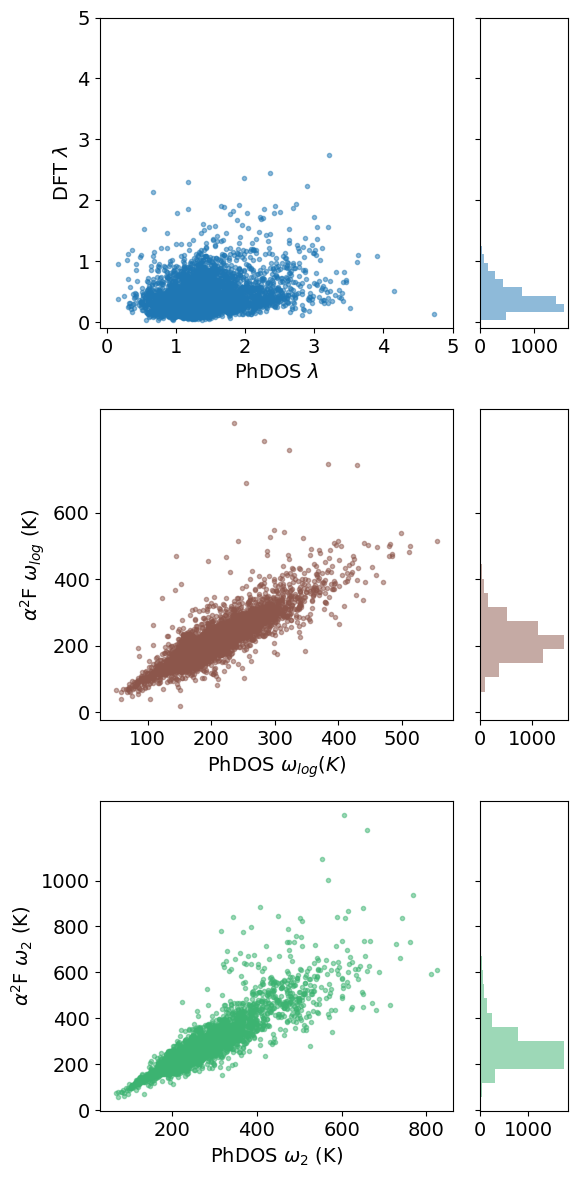

In [26]:
lreg = LinearRegression(fit_intercept=True,copy_X=True)

plt.clf()
plt.rcParams.update({'font.size': 14})
plt.rcParams["font.family"] = "sans-serif"

plt.subplots_adjust(left=0.05,bottom=0.07,right=0.99,top=0.99)
fig, axs = plt.subplots(3,2,figsize=(6,12),width_ratios=(4,1),sharey='row')

# #X_train, Y_train = np.array([training_data["dos_at_ef"]]), training_data["lambda"]
# X_train, Y_train = np.array(training_data["phlam"]), np.array(training_data["lambda"])
# mask = ~np.isnan(X_train) & ~np.isnan(Y_train)
# X_train = np.array([X_train[mask]])
# Y_train = Y_train[mask]

# #X_test, Y_test = np.array([testing_data["dos_at_ef"]]), testing_data["lambda"]
# X_test, Y_test = np.array(testing_data["phlam"]), np.array(testing_data["lambda"])
# mask = ~np.isnan(X_test) & ~np.isnan(Y_test)
# X_test = np.array([X_test[mask]])
# Y_test = np.array(Y_test[mask])


# reg = lreg.fit(X_train.transpose(),Y_train)

axs[0][0].scatter(data3['phlam'],data3['ACH_lambda_sigma_2'],marker='.',alpha=0.5,color='C0')
axs[0][1].hist(data3['ACH_lambda_sigma_2'],alpha=0.5,color='C0',orientation='horizontal',bins=20)

axs[0][0].set_xlabel(r"PhDOS $\lambda$")
axs[0][0].set_ylabel(r"DFT $\lambda$")

# X_data, Y_data = np.array(data3["phlam"]), np.array(data3["ACH_lambda_sigma_2"])
# mask = ~np.isnan(X_data) & ~np.isnan(Y_data)
# X_data = np.array([X_data[mask]])
# Y_data = Y_data[mask]
# data_pear_r = r_regression(X_data.transpose(),Y_data)

# print("Lambda:\n"+
#       r"Data Pearson r ="+str(round(data_pear_r[0],2)))# + "\n" +
#       r"Training $R^2$ ="+str(round(reg.score(X_train.transpose(),Y_train),2)) + "\n" + 
#       r"Training MAE ="+str(round(mean_absolute_error(Y_train, reg.predict(X_train.transpose())),2)) + "\n" +
#       r"Training RMSE ="+str(round(mean_squared_error(Y_train, reg.predict(X_train.transpose()), squared=False),2)) + "\n" +
#       "\n" +
#       r"Testing $R^2$ ="+str(round(reg.score(X_test.transpose(),Y_test),2)) + "\n"
#       r"Testing MAE ="+str(round(mean_absolute_error(Y_test, reg.predict(X_test.transpose())),2)) + "\n" +
#       r"Testing RMSE ="+str(round(mean_squared_error(Y_test, reg.predict(X_test.transpose()), squared=False),2)) + "\n" )

axs[0][0].set_xlim(-0.1,5)
axs[0][0].set_ylim(-0.1,5)
# axs[0].set_aspect('equal')

# X_train, Y_train = np.array(training_data["phwlog"])/0.08617, np.array(training_data["w_log"])/0.08617
# mask = ~np.isnan(X_train) & ~np.isnan(Y_train)
# X_train = np.array([X_train[mask]])
# Y_train = Y_train[mask]

# X_test, Y_test = np.array(testing_data["phwlog"])/0.08617, np.array(testing_data["w_log"])/0.08617
# mask = ~np.isnan(X_test) & ~np.isnan(Y_test)
# X_test = np.array([X_test[mask]])
# Y_test = np.array(Y_test[mask])

# training_pear_r = r_regression(X_train.transpose(),Y_train)
# reg = lreg.fit(X_train.transpose(),Y_train)

axs[1][0].scatter(data3['phwlog']/0.08617,data3['ACH_w_log_sigma_2']/0.08617,marker='.',alpha=0.5,color='C5')
axs[1][1].hist(data3['ACH_w_log_sigma_2']/0.08617,alpha=0.5,color='C5',orientation='horizontal',bins=20)
#axs[1].plot(X_train.transpose(),reg.predict(X_train.transpose()),"k--")

axs[1][0].set_xlabel(r"PhDOS $\omega_{log} (K)$")
axs[1][0].set_ylabel(r"$\alpha^2$F $\omega_{log}$ (K)")

#axs[1][0].set_title(r"Pearson r ="+str(round(training_pear_r[0],2)))

# X_data, Y_data = np.array(data3["phwlog"])/0.08617, np.array(data3["ACH_w_log_sigma_2"])/0.08617
# mask = ~np.isnan(X_data) & ~np.isnan(Y_data)
# X_data = np.array([X_data[mask]])
# Y_data = Y_data[mask]
# data_pear_r = r_regression(X_data.transpose(),Y_data)


# print("omega_log:\n"+
#       r"Data Pearson r ="+str(round(data_pear_r[0],2)))# + "\n" +
#       r"Training $R^2$ ="+str(round(reg.score(X_train.transpose(),Y_train),2)) + "\n" +
#       r"Training MAE ="+str(round(mean_absolute_error(Y_train, reg.predict(X_train.transpose())),2)) + "K \n" +
#       r"Training RMSE ="+str(round(mean_squared_error(Y_train, reg.predict(X_train.transpose()), squared=False),2)) + "K \n" +
#       "\n" +
#       r"Testing $R^2$ ="+str(round(reg.score(X_test.transpose(),Y_test),2)) + "\n"
#       r"Testing MAE ="+str(round(mean_absolute_error(Y_test, reg.predict(X_test.transpose())),2)) + "K \n" +
#       r"Testing RMSE ="+str(round(mean_squared_error(Y_test, reg.predict(X_test.transpose()), squared=False),2)) + "K \n" )

xticks = axs[1][0].get_xticks()
axs[1][0].set_yticks(xticks)
#axs[1][0].set_xlim(-0.3,810)
#axs[1][0].set_ylim(-0.3,810)
# axs[1].set_aspect('equal')

# X_train, Y_train = np.array(training_data["phw2"])/0.08617, np.sqrt(training_data["w_sq"])/0.08617
# mask = ~np.isnan(X_train) & ~np.isnan(Y_train)
# X_train = np.array([X_train[mask]])
# Y_train = Y_train[mask]

# X_test, Y_test = np.array(testing_data["phw2"])/0.08617, np.sqrt(testing_data["w_sq"])/0.08617
# mask = ~np.isnan(X_test) & ~np.isnan(Y_test)
# X_test = np.array([X_test[mask]])
# Y_test = np.array(Y_test[mask])

# training_pear_r = r_regression(X_train.transpose(),Y_train)
# reg = lreg.fit(X_train.transpose(),Y_train)

axs[2][0].scatter(data3['phw2']/0.08617,np.sqrt(list(data3['ACH_w_sq_sigma_2']))/0.08617,
                  marker='.',alpha=0.5,
                  color='mediumseagreen')
axs[2][1].hist(np.sqrt(list(data3['ACH_w_sq_sigma_2']))/0.08617,
               alpha=0.5,color='mediumseagreen',orientation='horizontal',bins=20)

# axs[2][0].set_xlabel(r"PhDOS $\sqrt{\omega^2}$ (K)")
# axs[2][0].set_ylabel(r"$\alpha^2$F $\sqrt{\omega^2}$ (K)")

axs[2][0].set_xlabel(r"PhDOS $\omega_2$ (K)")
axs[2][0].set_ylabel(r"$\alpha^2$F $\omega_2$ (K)")

#axs[2][0].set_title(r"Pearson r ="+str(round(training_pear_r[0],2)))

# X_data, Y_data = np.array(data3["phw2"])/0.08617, np.sqrt(data3["ACH_w_sq_sigma_2"])/0.08617
# mask = ~np.isnan(X_data) & ~np.isnan(Y_data)
# X_data = np.array([X_data[mask]])
# Y_data = Y_data[mask]
# data_pear_r = r_regression(X_data.transpose(),Y_data)

# print("omega^2\n"+
#       r"Data Pearson r ="+str(round(data_pear_r[0],2)))# + "\n" +
      # r"Training $R^2$ ="+str(round(reg.score(X_train.transpose(),Y_train),2)) + "\n" +
      # r"Training MAE ="+str(round(mean_absolute_error(Y_train, reg.predict(X_train.transpose())),2)) + "K \n" +
      # r"Training RMSE ="+str(round(mean_squared_error(Y_train, reg.predict(X_train.transpose()), squared=False),2)) + "K \n" +
      # "\n" +
      # r"Testing $R^2$ ="+str(round(reg.score(X_test.transpose(),Y_test),2)) + "\n"
      # r"Testing MAE ="+str(round(mean_absolute_error(Y_test, reg.predict(X_test.transpose())),2)) + "K \n" +
      # r"Testing RMSE ="+str(round(mean_squared_error(Y_test, reg.predict(X_test.transpose()), squared=False),2)) + "K \n" )


xticks = axs[2][0].get_xticks()
axs[2][0].set_yticks(xticks)
#axs[2][0].set_xlim(-0.3,1000)
#axs[2][0].set_ylim(-0.3,1000)
# axs[2][0].set_aspect('equal')

plt.tight_layout()

In [29]:
data3

,comp,ID,dir_name,ase_atom_obj,a2F_Freq_meV_sigma_5,a2F_sigma_5,a2F_Freq_meV_sigma_2,a2F_sigma_2,PhFreq_meV,Tot_PhDOS,...,ACH_w_sq_sigma_2,ACH_w_sq_sigma_5,Ph_2x2x2_interpolated_Freq_meV,Ph_2x2x2_interpolated_Tot_DOS,Ph_2x2x2_interpolated_Site_Proj_DOS,AW,unitcell_vol,phlam,phwlog,phw2
0,TiZr2Hf,agm001117008,batch-a/TiZr2Hf_agm001117008,"(Atom('Hf', [1.5545413949488431, 1.55454139494...","[0.3099610662768737, 0.433944404331305, 0.5579...","[3.78827e-06, 1.0395e-05, 2.20932e-05, 9.63046...","[0.3099610662768737, 0.433944404331305, 0.5579...","[3.74098e-06, 1.02653e-05, 2.18174e-05, 0.0001...","[-3.27827707685721e-07, 0.12398392948682858, 0...","[0.0, 2.9633224103364845e-05, 0.00011853293754...",...,144.770021,146.740253,"[-2.8712443137094725e-07, 0.1000005794401343, ...","[0.0, 3.592022115913284e-05, 0.000143681216501...","[[0.0, 1.5672150981763196e-05, 6.2643436902454...","[178.49, 91.224, 91.224, 47.867]",82.790253,2.025927,10.999947,13.204543
1,Ti2Tc,agm001850181,batch-a/Ti2Tc_agm001850181,"(Atom('Ti', [0.0, 0.0, 6.17470978133578], inde...","[0.3099597057064761, 0.433944404331305, 0.5579...","[3.65996e-06, 1.00429e-05, 2.43003e-05, 6.0852...","[0.3099597057064761, 0.433944404331305, 0.5579...","[4.54172e-06, 1.24625e-05, 2.97945e-05, 7.3975...","[-7.408069556149091e-07, 0.12398351650766588, ...","[0.0, 9.28629968461457e-06, 3.714520594501837e...",...,442.509367,440.894069,"[-6.86077933671161e-07, 0.10000018048607079, 0...","[0.0, 1.7984255786101776e-06, 7.19371149923581...","[[0.0, 4.442499490893504e-07, 1.77578996534136...","[47.867, 47.867, 97.90721]",45.683695,0.847788,19.976235,22.268911
2,TiNb2Mo,agm002322068,batch-a/TiNb2Mo_agm002322068,"(Atom('Ti', [0.0, 0.0, 0.0], index=0), Atom('N...","[0.3099597057064761, 0.433944404331305, 0.5579...","[1.0947e-05, 3.00387e-05, 6.38432e-05, 0.00027...","[0.3099597057064761, 0.433944404331305, 0.5579...","[1.24171e-05, 3.40725e-05, 7.24166e-05, 0.0002...","[-6.26661135782e-07, 0.12398363065377238, 0.24...","[0.0, 3.374342803196467e-05, 0.000134973774666...",...,352.305877,348.385639,"[-3.8213266591462075e-07, 0.1000004844309979, ...","[0.0, 1.720332688031231e-05, 6.8813314894766e-...","[[0.0, 2.5053180680126003e-06, 1.0049662973226...","[47.867, 92.90637, 92.90637, 95.95]",66.085084,1.394697,15.328235,18.122709
3,Cr4TaW,agm003199689,batch-a/Cr4TaW_agm003199689,"(Atom('Ta', [5.09579831601969, 5.0957983160196...","[0.3099597057064761, 0.433944404331305, 0.5579...","[5.095e-07, 1.39807e-06, 2.97141e-06, 5.42516e...","[0.3099597057064761, 0.433944404331305, 0.5579...","[6.89006e-07, 1.89063e-06, 4.01829e-06, 7.3365...","[-1.1285933676141665e-06, 0.12398312872086444,...","[0.0, 1.188429008013745e-05, 4.753726013483484...",...,462.433832,484.472165,"[-1.170317608711315e-06, 0.0999996962469562, 0...","[0.0, 1.2351614770826739e-05, 4.94067870305873...","[[0.0, 3.904205344157425e-06, 1.56253708491430...","[180.94788, 51.9961, 51.9961, 51.9961, 51.9961...",78.413874,1.789248,17.902765,22.689554
4,ScZr2Hf,agm001224362,batch-a/ScZr2Hf_agm001224362,"(Atom('Hf', [2.231190766080766, 2.231190766080...","[0.3099597057064761, 0.433944404331305, 0.5579...","[1.98777e-06, 5.45444e-06, 1.15927e-05, 2.8097...","[0.3099597057064761, 0.433944404331305, 0.5579...","[2.71001e-06, 7.43627e-06, 1.58048e-05, 3.8586...","[-4.7407814988331473e-07, 0.12398378323623849,...","[0.0, 2.5589694772645687e-05, 0.00010235881498...",...,191.259416,193.25882,"[-4.422155281254245e-07, 0.10000042434822681, ...","[0.0, 1.7738153301311985e-05, 7.09527339213801...","[[0.0, 7.842608578368205e-06, 3.15402945881246...","[178.49, 91.224, 91.224, 44.955908]",88.499474,1.700905,12.417268,14.220628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5237,Al2ZnMo,agm003186213,batch-q/Al2ZnMo_agm003186213,"(Atom('Al', [0.0, 0.0, 4.243290309763619], ind...","[0.3099610662768737, 0.433944404331305, 0.5579...","[4.70358e-08, 1.29066e-07, 2.74313e-07, 5.0083...","[0.3099610662768737, 0.433944404331305, 0.5

In [28]:
data3.to_pickle("qe_data_imaginary_removed_w_Ph_2x2x2_interpolated_DOS.pkl")

In [114]:
data3[data3['phwlog']/0.08617 <= 50][["dir_name","phwlog","ACH_w_log_sigma_2"]]

,dir_name,phwlog,ACH_w_log_sigma_2
41,batch-a/N4ScHf3_agm003557883,0.858381,21.477578
63,batch-a/ZrNbTa_agm001839730,3.725712,13.549953
71,batch-a/Cr4NbW_agm001173535,0.250333,17.741171
112,batch-a/ZrHf_agm004451102,1.448806,11.274664
129,batch-a/P4Zr3Hf_agm003562840,1.982179,9.332285
...,...,...,...
4583,batch-n/AlCu2Zn_agm002134662,2.986728,16.951052
4883,batch-o/Al2Ni3Cu_agm003437123,0.270270,19.102504
5122,batch-p/As2ZrHf_agm005120946,0.402166,16.795058
5202,batch-p/Cu2ZnGa_agm002146024,2.942377,15.895116


In [109]:
temp[["phwlog","ACH_w_log_sigma_2"]]

,phwlog,ACH_w_log_sigma_2
41,0.858381,21.477578
63,3.725712,13.549953
71,0.250333,17.741171
112,1.448806,11.274664
129,1.982179,9.332285
...,...,...
4583,2.986728,16.951052
4883,0.270270,19.102504
5122,0.402166,16.795058
5202,2.942377,15.895116


In [7]:
import ase.io

In [10]:
ase_atom = ase.io.read("batch-b/B2Mg_agm002077195/scf_coarse.in")

In [12]:
import subprocess

In [38]:
proc = subprocess.Popen(["grep -A 1 'K_POINTS' batch-b/B2Mg_agm002077195/scf_coarse.in"],
                        stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT,shell=True)

output, error = proc.communicate()
output = output.decode("utf-8")
output = output.split()
k_grid = [int(output[2]), int(output[3]), int(output[4])] 

In [39]:
k_grid

[8, 8, 8]

In [33]:
output

b'K_POINTS automatic\n  8 8 8 0 0 0\n'

['K_POINTS', 'automatic', '8', '8', '8', '0', '0', '0']